# Constrained lake analysis


## Setup


In [3]:
import os, re
import numpy as np
import pandas as pd
import analysis_lib as A
from analysis_lib import (
    MORL_METHODS, MOEA_METHODS, ORDER,
    METHOD_LABEL, PARADIGM_OF, PARADIGM_COLOR, N_OBJS_DEFAULT,
)

N_OBJS = N_OBJS_DEFAULT  # [2, 6]

METRICS = [
    dict(col='hv_ratio',     base='hv_ratio',
         ylabel='HV (normalised)',      better='higher'),
    dict(col='spacing_norm', base='spacing_norm',
         ylabel='spacing (normalised)', better='lower'),
]

In [4]:
rt_rows = (
    A.collect_runtimes(os.path.dirname(MOEA_CSV),
        folder_re=MOEA_FOLDER_RE, paradigm='MOEA',
        condition_format=moea_fmt, csv_prefix='convergences_',
        mode='per_file')
    + A.collect_runtimes(os.path.dirname(MORL_CSV),
        folder_re=MORL_FOLDER_RE, paradigm='MORL',
        condition_format=morl_fmt, csv_prefix='convergence_',
        mode='per_file')
)
rt_df = pd.DataFrame(rt_rows)
print(f'Total runs: {len(rt_df)}')
A.summarize_runtimes(rt_df, title='Deterministic constrained lake runtime', metrics_df=df, modes=MODES)

NameError: name 'MOEA_CSV' is not defined

## Robust
In robust data, strict and tolerant differ — set `MODES = ['tolerant']` to see both as separate rows in the figures, or pick one.


### Configuration


In [5]:
MORL_CSV = '../data/constrained_lake/robust/morl/metrics_long_reeval.csv'
MOEA_CSV = '../data/constrained_lake/robust/moea/metrics_long_reeval.csv'
OUT_DIR  = './constrained_lake_figures'

MODES = ['tolerant']

CONDITION_STYLE = {
    'closed_loop_multi':   dict(alpha=0.55, hatch=''),
    'closed_loop_moro':    dict(alpha=0.30, hatch='..'),
    'intertemporal_multi': dict(alpha=0.55, hatch=''),
    'intertemporal_moro':  dict(alpha=0.55, hatch='..'),
    'dps_multi':           dict(alpha=0.35, hatch=''),
    'dps_moro':            dict(alpha=0.35, hatch='..'),
}
CONDITION_LABEL = {
    'closed_loop_multi':   'closed-loop · multi',
    'closed_loop_moro':    'closed-loop · ro',
    'intertemporal_multi': 'intertemporal · multi',
    'intertemporal_moro':  'intertemporal · ro',
    'dps_multi':           'DPS · multi',
    'dps_moro':            'DPS · ro',
}
CONDITION_ORDER = [
    'closed_loop_multi', 'closed_loop_moro',
    'intertemporal_multi', 'intertemporal_moro',
    'dps_multi', 'dps_moro',
]

MOEA_FOLDER_RE = re.compile(
    r'^(intertemporal|dps)_(NSGAII|IBEA|MOEAD)_(multi|moro)_(\d+)$')
MORL_FOLDER_RE = re.compile(
    r'^(pareto|indicator|decomposition)_(multi|moro)_(\d+)$')

def moea_fmt(groups):
    policy, algo, scenm, n_obj = groups
    return f'{policy}_{scenm}', algo, int(n_obj)

def morl_fmt(groups):
    scoring, scenm, n_obj = groups
    return f'closed_loop_{scenm}', scoring, int(n_obj)

### Load + summary


In [6]:
df = A.load_metrics(MORL_CSV, MOEA_CSV, metrics=METRICS,
                    modes=MODES)
A.print_metric_summary(df, metrics=METRICS, n_objs=N_OBJS,
                       condition_order=CONDITION_ORDER,
                       modes=MODES)

paradigm method        condition                    n_obj    n    n_dom·tol     ±std    hv_ratio·tol      ±std  spacing_norm·t      ±std
MORL     PQL-Pareto    closed_loop_multi                2   10        129.7     27.3         0.42359   0.02164         0.00181   0.00046
MORL     PQL-Pareto    closed_loop_moro                 2   10          9.7      7.8         0.36756   0.06909         0.00337   0.00163
MORL     PQL-Indicator closed_loop_multi                2   10        145.0     44.3         0.39985   0.03508         0.00187   0.00030
MORL     PQL-Indicator closed_loop_moro                 2   10          9.5      5.0         0.30054   0.02216         0.00211   0.00034
MORL     PQL-Decomp    closed_loop_multi                2   10        209.0     35.0         0.41384   0.02314         0.00174   0.00054
MORL     PQL-Decomp    closed_loop_moro                 2   10         15.8     12.5         0.35855   0.06309         0.00282   0.00106
MOEA     NSGA-II       intertemporal_mult

### Figure 1 — HV ratio + spacing (box plots)


Saved ./constrained_lake_figures/fig1_robust_constrained_lake_metrics_tolerant_hv_ratio.png
Saved ./constrained_lake_figures/fig1_robust_constrained_lake_metrics_tolerant_spacing_norm.png


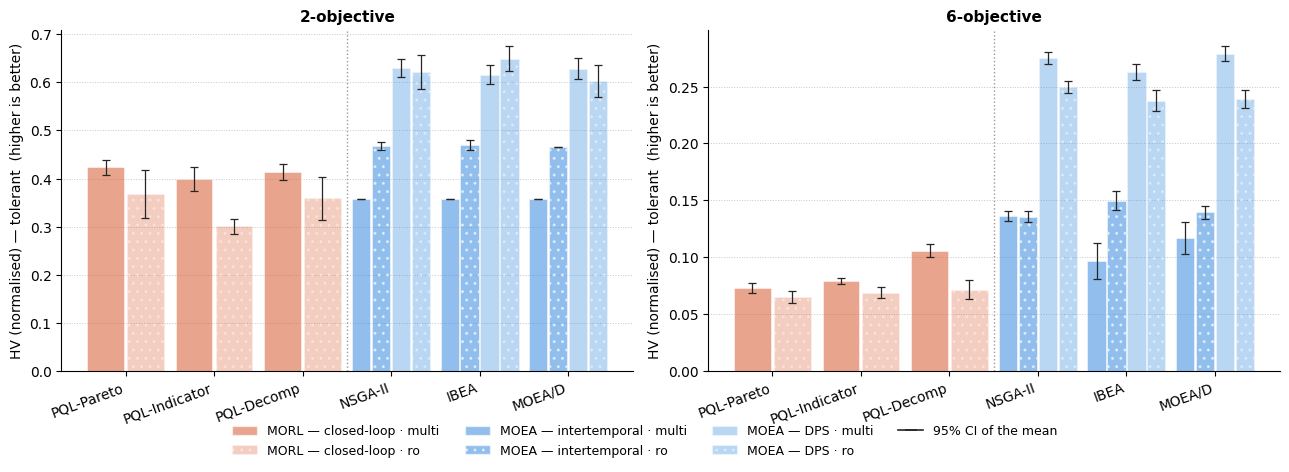

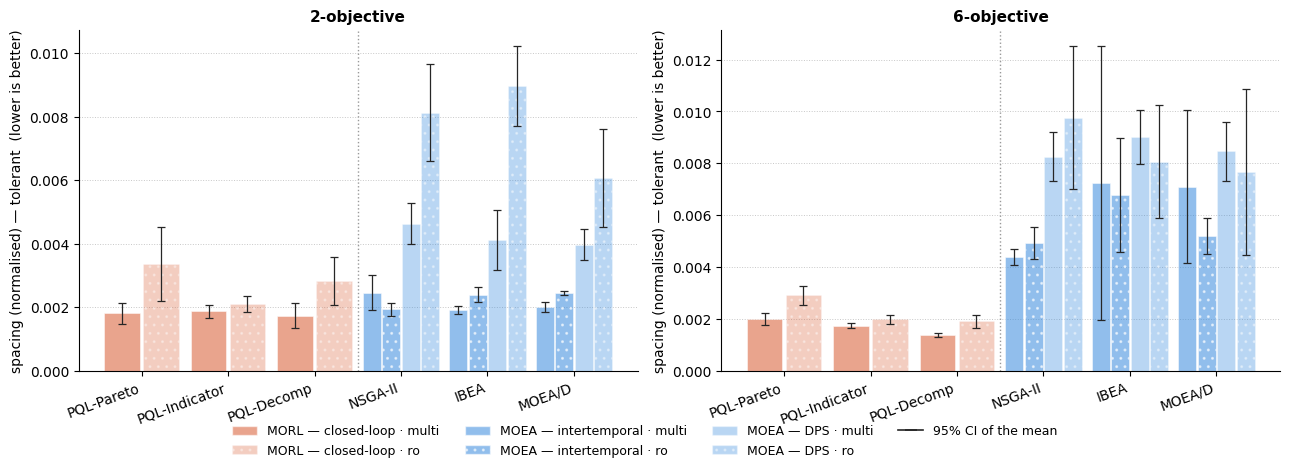

In [7]:
A.figure_metrics_separate(
    df, metrics=METRICS, n_objs=N_OBJS, modes=MODES,
    condition_style=CONDITION_STYLE,
    condition_label=CONDITION_LABEL,
    condition_order=CONDITION_ORDER,
    # suptitle='MORL vs MOEA — robust constrained lake (closed-loop)',
    out_path=os.path.join(OUT_DIR, f'fig1_robust_constrained_lake_metrics_{MODES[0]}.png'))

### Figure 2 — Solution counts


Saved ./constrained_lake_figures/fig2_robust_constrained_lake_counts_tolerant.png


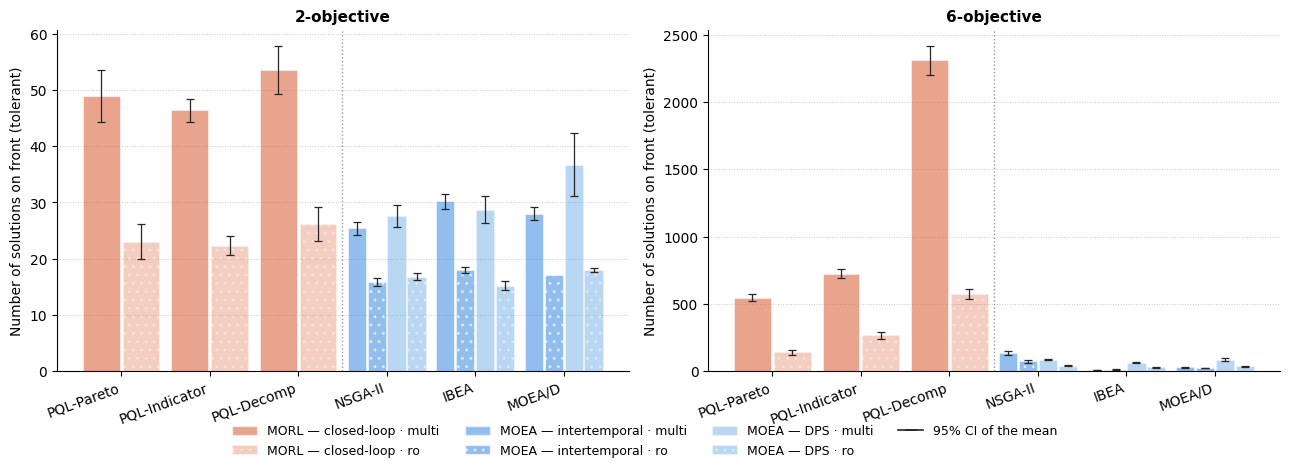

In [8]:
A.figure_counts(
    df, n_objs=N_OBJS, modes=MODES,
    condition_style=CONDITION_STYLE,
    condition_label=CONDITION_LABEL,
    condition_order=CONDITION_ORDER,
    # suptitle='Number of solutions on the re-evaluated front — '
    #          'robust constrained lake',
    out_path=os.path.join(OUT_DIR, f'fig2_robust_constrained_lake_counts_{MODES[0]}.png'))

### Figure 3 — Convergence (MOEA + MORL)


MOEA: 720 curves; MORL: 360 curves
Saved ./constrained_lake_figures/fig3_robust_constrained_lake_conv_moea.png
Saved ./constrained_lake_figures/fig3_robust_constrained_lake_conv_morl.png


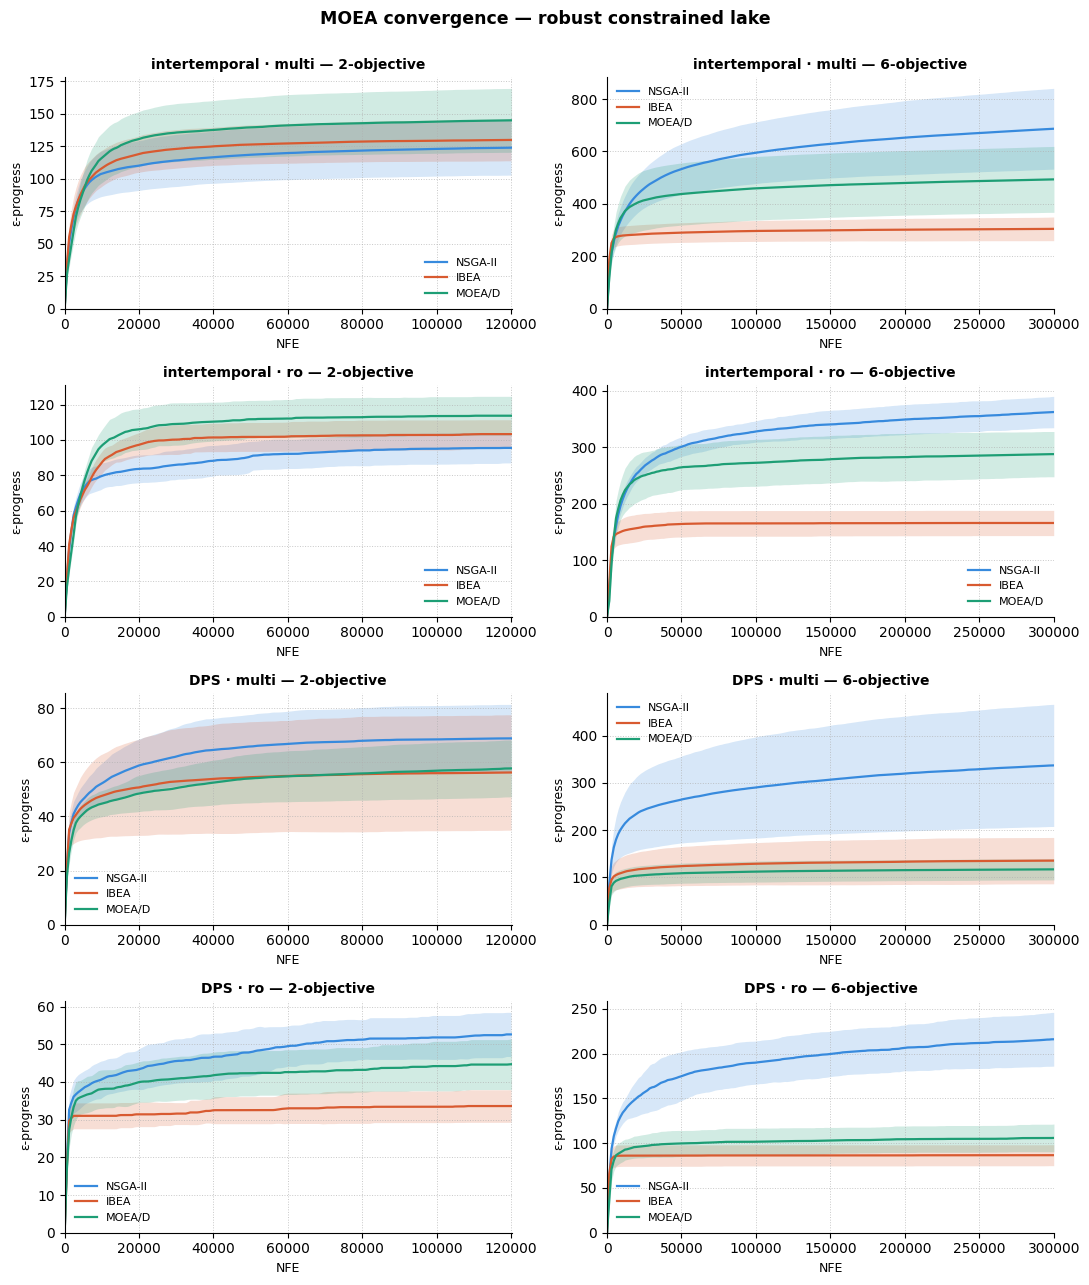

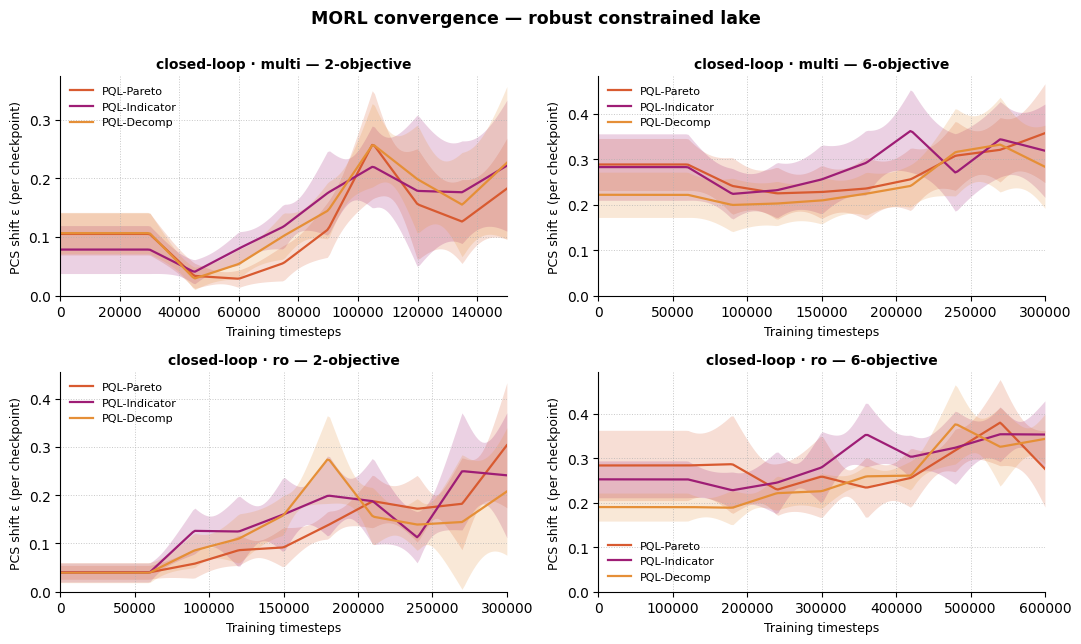

In [9]:
moea_records = A.load_convergences(
    os.path.dirname(MOEA_CSV), folder_re=MOEA_FOLDER_RE,
    condition_format=moea_fmt, csv_prefix='convergences_',
    x_col='nfe', y_col='epsilon_progress')
morl_records = A.load_convergences(
    os.path.dirname(MORL_CSV), folder_re=MORL_FOLDER_RE,
    condition_format=morl_fmt, csv_prefix='convergence_',
    x_col='timestep', y_col='pcs_shift_eps', dropna_y=True)
print(f'MOEA: {len(moea_records)} curves; '
      f'MORL: {len(morl_records)} curves')

A.figure_convergence(
    moea_records, methods=MOEA_METHODS,
    conditions=['intertemporal_multi', 'intertemporal_moro',
                'dps_multi', 'dps_moro'],
    n_objs=N_OBJS, cond_labels=CONDITION_LABEL,
    xlabel='NFE', ylabel='ε-progress',
    suptitle='MOEA convergence — robust constrained lake',
    out_path=os.path.join(OUT_DIR, 'fig3_robust_constrained_lake_conv_moea.png'))

A.figure_convergence(
    morl_records, methods=MORL_METHODS,
    conditions=['closed_loop_multi', 'closed_loop_moro'],
    n_objs=N_OBJS, cond_labels=CONDITION_LABEL,
    xlabel='Training timesteps',
    ylabel='PCS shift ε (per checkpoint)',
    suptitle='MORL convergence — robust constrained lake',
    out_path=os.path.join(OUT_DIR, 'fig3_robust_constrained_lake_conv_morl.png'))

### Runtime summary


In [10]:
rt_rows = (
    A.collect_runtimes(os.path.dirname(MOEA_CSV),
        folder_re=MOEA_FOLDER_RE, paradigm='MOEA',
        condition_format=moea_fmt, csv_prefix='convergences_',
        mode='per_seed')
    + A.collect_runtimes(os.path.dirname(MORL_CSV),
        folder_re=MORL_FOLDER_RE, paradigm='MORL',
        condition_format=morl_fmt, csv_prefix='convergence_',
        mode='per_seed')
)
rt_df = pd.DataFrame(rt_rows)
print(f'Total runs: {len(rt_df)}')
A.summarize_runtimes(rt_df, title='Robust constrained lake runtime', metrics_df=df, modes=MODES)

Total runs: 360

=== Robust constrained lake runtime ===



,paradigm,method,condition,n_obj,count,mean_hms,std_hms,total_hms,n_infeasible_tolerant_mean,n_infeasible_tolerant_std,n_dom_tolerant_mean,n_dom_tolerant_std,n_solutions_tolerant_mean,n_solutions_tolerant_std
0,MOEA,IBEA,dps_moro,2,10,18m02s,1m33s,3h00m20s,0.0,0.0,0.8,0.9,15.2,1.1
1,MOEA,IBEA,dps_moro,6,10,1h20m58s,3m04s,13h29m40s,0.7,0.7,0.0,0.0,27.5,4.5
2,MOEA,IBEA,dps_multi,2,10,25m15s,1m12s,4h12m30s,60.8,5.1,14.6,3.3,28.7,3.4
3,MOEA,IBEA,dps_multi,6,10,3h31m26s,8m57s,35h14m20s,162.9,9.6,2.1,1.8,61.8,8.5
4,MOEA,IBEA,intertemporal_moro,2,10,18m30s,2m30s,3h05m00s,0.8,0.6,0.1,0.3,17.9,0.7
5,MOEA,IBEA,intertemporal_moro,6,10,1h30m02s,6m37s,15h00m20s,5.7,1.8,0.0,0.0,9.9,1.9
6,MOEA,IBEA,intertemporal_multi,2,10,27m42s,1m22s,4h37m00s,70.8,2.0,11.8,1.7,30.2,1.8
7,MOEA,IBEA,intertemporal_multi,6,10,3h41m05s,8m28s,36h50m50s,87.9,10.1,0.3,0.7,5.3,2.4
8,MOEA,MOEAD,dps_moro,2,10,17m03s,1m39s,2h50m30s,0.2,0.4,0.1,0.3,18.0,0.5
9,MOEA,MOEAD,dps_moro,6,10,47m30s,3m00s,7h55m00s,0.6,1.0,0.1,0.3,35.5,4.6
